In [1]:
import pandas as pd

In [2]:
from google.colab import files

uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [3]:
df = pd.read_csv("winequality-red.csv", sep=";")

# Wine Quality Prediction

## Dataset Inspection

In this project, we analyse the Wine Quality dataset to predict wine quality based on its physicochemical properties.

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## Checking Duplicate Records

Duplicate records can affect the analysis and machine learning model. Therefore, we check the dataset for duplicate rows before continuing with the analysis.

In [8]:
df.duplicated().sum()

np.int64(240)

## Removing Duplicate Records

The dataset contains 240 duplicate rows. These duplicate records are removed to prevent them from affecting the analysis and machine learning model.

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(1359, 12)

## Quality Score Distribution

Before building the classification models, we examine how the wine quality scores are distributed. This helps us identify whether some quality classes are underrepresented and whether class imbalance may affect model performance.

In [11]:
df["quality"].value_counts().sort_index()

,count
quality,
3,10
4,53
5,577
6,535
7,167
8,17


### Observation

The quality scores are highly imbalanced. Quality scores 5 and 6 contain most of the wine samples, while scores 3 and 8 have very few samples. This imbalance may cause machine learning models to perform better on the majority classes than on the minority classes.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

### Quality Score Distribution

The following chart shows the number of wines for each quality score. It helps us visually understand the class imbalance in the dataset.

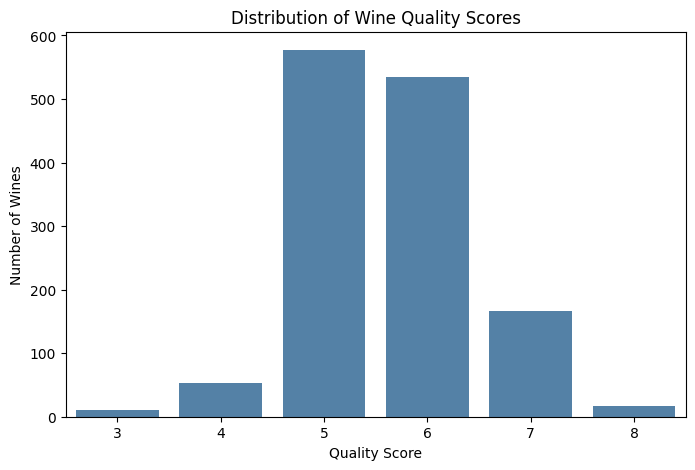

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique()),
    color="steelblue"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.show()

## Distribution of Chemical Features

The distribution of the physicochemical features helps us understand the range and spread of the variables in the wine dataset. These distributions are useful for identifying differences in scale and potential unusual values.

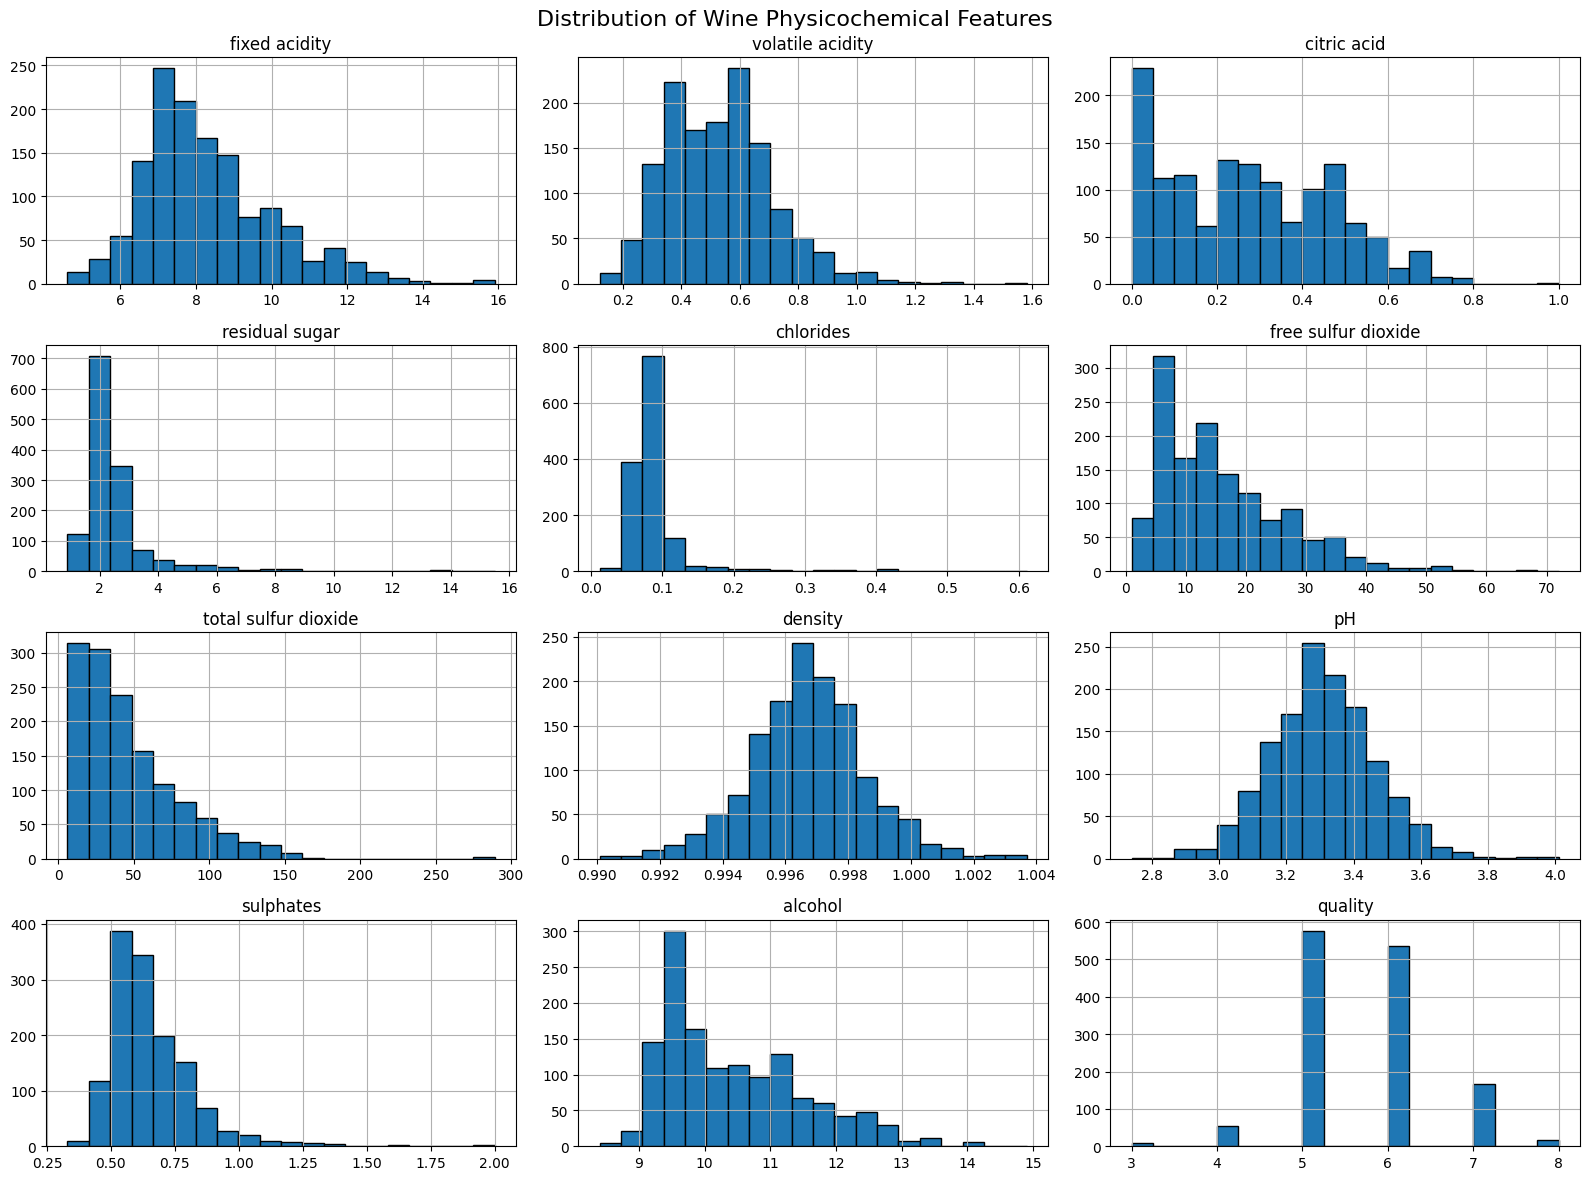

In [15]:
df.hist(
    figsize=(16, 12),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Wine Physicochemical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Correlation Heatmap

A correlation heatmap is used to examine the relationships between the physicochemical features and wine quality. It helps identify which variables have relatively strong positive or negative relationships with the target variable.

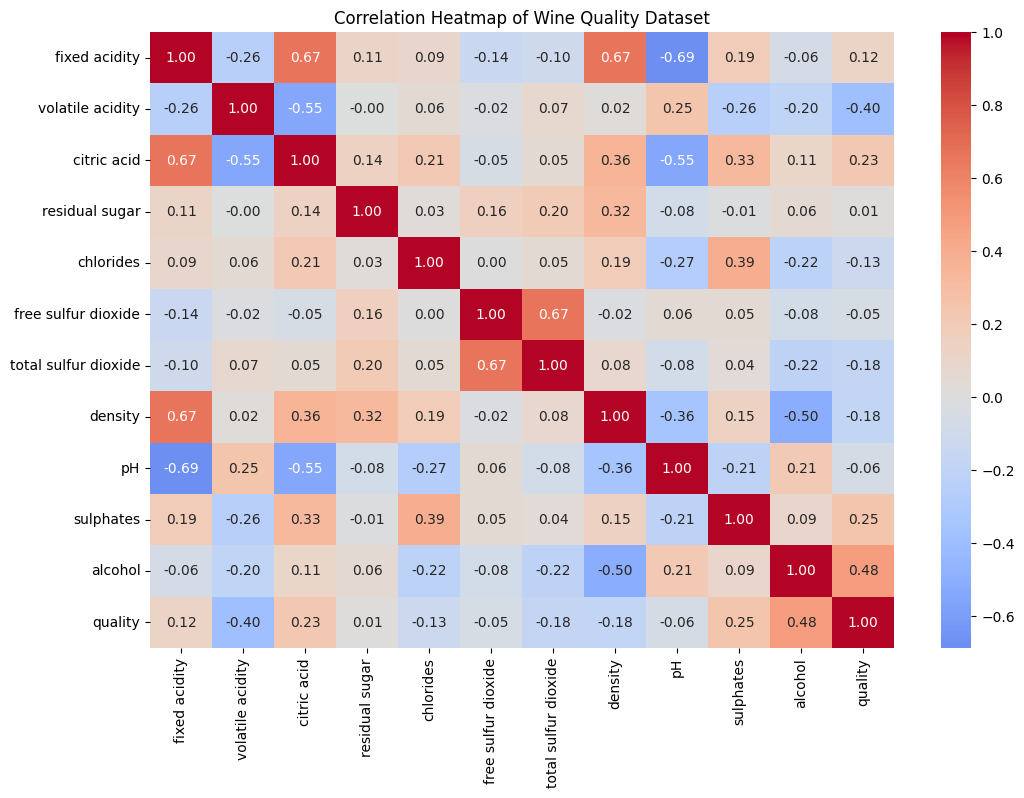

In [16]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Wine Quality Dataset")
plt.show()

## Feature Engineering: Grouping Wine Quality

The original quality scores are grouped into three categories to create a practical three-class classification problem.

- Quality 3–4: Low
- Quality 5–6: Medium
- Quality 7–8: High

This grouping reduces the effect of classes with very few observations while preserving the overall meaning of wine quality.

In [17]:
def quality_group(quality):
    if quality <= 4:
        return "Low"
    elif quality <= 6:
        return "Medium"
    else:
        return "High"

df["quality_group"] = df["quality"].apply(quality_group)

In [18]:
df["quality_group"].value_counts()

,count
quality_group,
Medium,1112
High,184
Low,63


### Observation

After grouping the quality scores, the Medium category contains the majority of the wines, while the Low category contains the fewest samples. This confirms that the three-class dataset remains imbalanced, which should be considered when evaluating the classification models.

/tmp/ipykernel_738/215620829.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


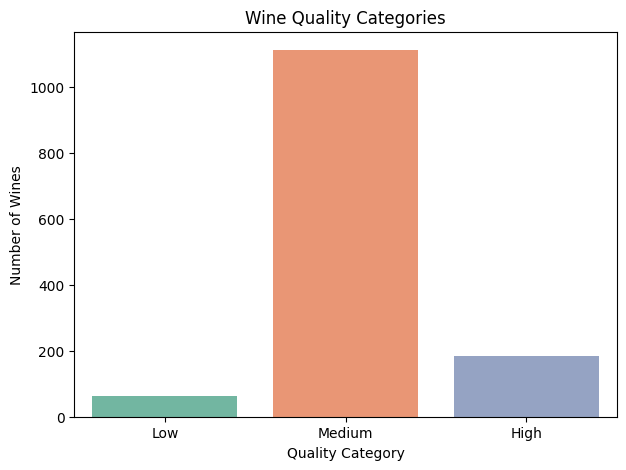

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality_group",
    order=["Low", "Medium", "High"],
    palette="Set2"
)

plt.title("Wine Quality Categories")
plt.xlabel("Quality Category")
plt.ylabel("Number of Wines")

plt.show()

## Feature and Target Selection

The physicochemical properties of the wine will be used as input features, while the newly created `quality_group` will be the target variable that the machine learning models will predict.

The original `quality` column is removed because it was used to create the target categories.

In [20]:
X = df.drop(columns=["quality", "quality_group"])
y = df["quality_group"]

In [21]:
print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target: quality_group


## Train-Test Split

The dataset is divided into 80% training data and 20% testing data. Stratified splitting is used to preserve the proportion of Low, Medium, and High quality wines in both the training and testing sets.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Feature Standardization

The physicochemical features have different numerical scales. StandardScaler is used to standardize the features before training the SGD and SVC models. The scaler is fitted only on the training data to avoid data leakage.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions. It is suitable for this dataset because it can capture non-linear relationships between the physicochemical properties and wine quality.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

## Random Forest Prediction

The trained Random Forest model is now used to predict the quality category of the wines in the test dataset.

In [25]:
rf_pred = rf_model.predict(X_test)

rf_pred[:10]

array(['Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'High',
       'Medium', 'Medium', 'Medium'], dtype=object)

## Random Forest Model Evaluation

The Random Forest model is evaluated using accuracy, precision, recall, and F1-score. These metrics provide a more complete view of model performance, especially because the wine quality classes are imbalanced.

In [26]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8198529411764706

Classification Report:
              precision    recall  f1-score   support

        High       0.57      0.32      0.41        37
         Low       0.33      0.15      0.21        13
      Medium       0.85      0.94      0.90       222

    accuracy                           0.82       272
   macro avg       0.59      0.47      0.51       272
weighted avg       0.79      0.82      0.80       272



## Random Forest Confusion Matrix

The confusion matrix shows how many wines from each actual quality category were correctly or incorrectly classified by the Random Forest model.

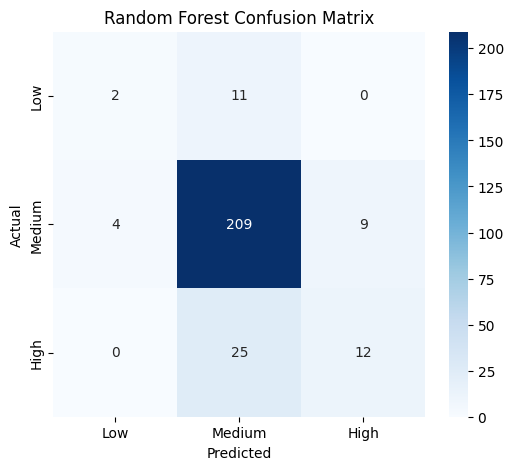

In [27]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model 2: Stochastic Gradient Descent (SGD) Classifier

SGD is a linear classification algorithm that is efficient for large datasets. The standardized features are used because SGD is sensitive to differences in feature scales.

In [28]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

SGDClassifier(random_state=42)

## SGD Model Evaluation

The trained SGD classifier is used to predict the wine quality categories in the test dataset. Its performance is evaluated using accuracy, precision, recall, and F1-score.

In [29]:
from sklearn.metrics import accuracy_score, classification_report

sgd_pred = sgd_model.predict(X_test_scaled)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", sgd_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, sgd_pred))

SGD Accuracy: 0.8051470588235294

Classification Report:
              precision    recall  f1-score   support

        High       0.44      0.41      0.42        37
         Low       1.00      0.08      0.14        13
      Medium       0.86      0.91      0.88       222

    accuracy                           0.81       272
   macro avg       0.77      0.47      0.48       272
weighted avg       0.81      0.81      0.79       272



## Model 3: Support Vector Classifier (SVC)

Support Vector Classifier is a supervised machine learning algorithm that finds a decision boundary between different classes. Standardized features are used because SVC is sensitive to feature scale.

In [30]:
from sklearn.svm import SVC

svc_model = SVC(
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

## SVC Model Evaluation

The SVC model is used to predict the wine quality categories in the test dataset. Its performance is evaluated using accuracy, precision, recall, and F1-score.

In [31]:
svc_pred = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, svc_pred))

SVC Accuracy: 0.8455882352941176

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.24      0.38        37
         Low       0.00      0.00      0.00        13
      Medium       0.84      1.00      0.91       222

    accuracy                           0.85       272
   macro avg       0.58      0.41      0.43       272
weighted avg       0.81      0.85      0.80       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model Performance Comparison

The three classification models are compared using their accuracy scores. This comparison helps identify the model with the best overall predictive performance.

However, because the dataset is imbalanced, accuracy alone should not be used to select the final model. Precision, recall, and F1-score for minority classes should also be considered.

In [32]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(3)

comparison

,Model,Accuracy
0,Random Forest,0.820
1,SGD,0.805
2,SVC,0.846


## Model Accuracy Comparison

The SVC model achieved the highest overall accuracy at approximately 84.6%, followed by Random Forest at 82.0% and SGD at 80.5%. However, due to class imbalance, the minority-class performance should also be considered before selecting a model for deployment.

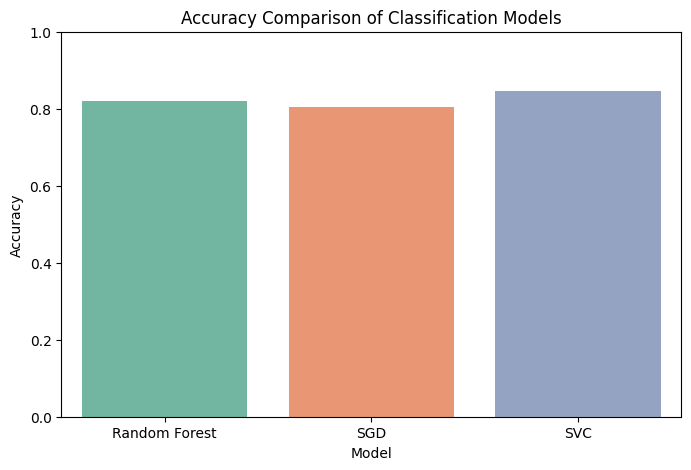

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Accuracy Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

## Feature Importance — Random Forest

Random Forest provides feature importance scores that show which physicochemical properties contribute most to the model's predictions. This helps us understand which characteristics are most useful for predicting wine quality.

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
10,alcohol,0.151730
1,volatile acidity,0.117394
9,sulphates,0.113169
7,density,0.091047
6,total sulfur dioxide,0.089182
2,citric acid,0.082148
0,fixed acidity,0.078966
3,residual sugar,0.076459
4,chlorides,0.069741
8,pH,0.068442


### Feature Importance Observation

The Random Forest model identifies alcohol as the most important feature for predicting wine quality, followed by volatile acidity and sulphates. Free sulfur dioxide has the lowest importance among the selected features.

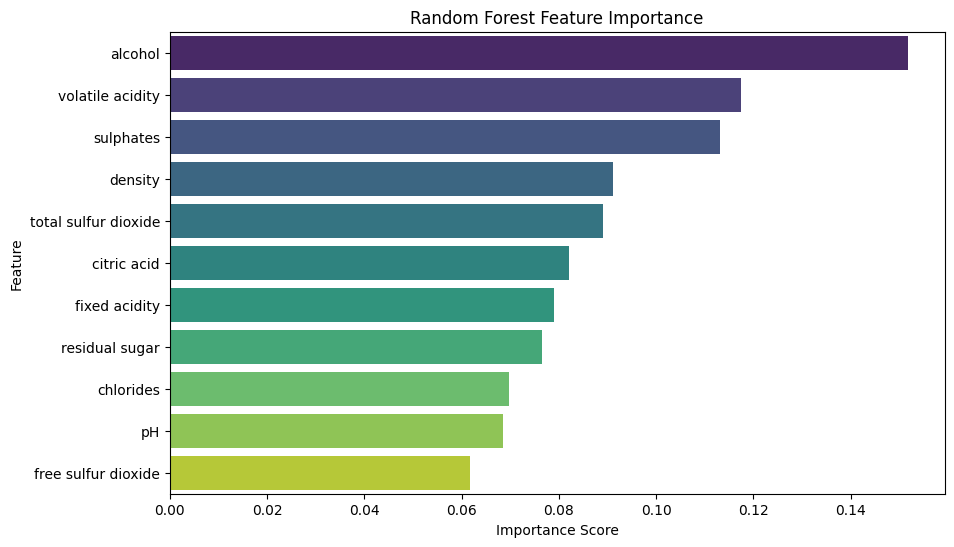

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

# Conclusion

In this project, three machine learning models — Random Forest, SGD Classifier, and Support Vector Classifier (SVC) — were trained to predict wine quality categories.

The SVC model achieved the highest overall accuracy of 84.6%, followed by Random Forest with 82.0% and SGD with 80.5%.

However, the dataset was highly imbalanced, with the Medium quality category containing most of the samples. As a result, all models performed much better on the Medium class than on the Low and High classes.

The Random Forest feature importance analysis showed that alcohol, volatile acidity, and sulphates were among the most important features for predicting wine quality.

## Key Findings

1. SVC achieved the highest overall accuracy (84.6%).
2. Wine quality classes were highly imbalanced, with Medium quality being dominant.
3. Alcohol was the most important feature according to the Random Forest model.

## Final Recommendation

SVC can be considered the best model based on overall accuracy. However, because of the class imbalance and poor prediction of minority classes, further improvements such as class weighting, resampling techniques, or additional data for Low and High quality wines should be considered before deployment.